In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
import math
# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go



from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src import utils  
from src.config import Config 

cfg = Config


# -------------------------------------------------------

sys.path contains: /home/ismail


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:


df_train = pd.read_csv("train.csv")
# X_test = pd.read_csv("test.csv")


target = cfg.TARGET
X_train = df_train.drop(columns=[target])
y_train = df_train[target]



print("X_train shape:", X_train.shape)
# print("X_test shape:", X_test.shape)


X_train shape: (24236806, 9)


In [34]:
asset_details = pd.read_csv("asset_details.csv")
asset_det = asset_details.set_index("Asset_ID")
asset_det

,Weight,Asset_Name
Asset_ID,,
2,2.397895,Bitcoin Cash
0,4.304065,Binance Coin
1,6.779922,Bitcoin
5,1.386294,EOS.IO
7,2.079442,Ethereum Classic
6,5.894403,Ethereum
9,2.397895,Litecoin
11,1.609438,Monero
13,1.791759,TRON


In [5]:
X_train

,timestamp,Asset_ID,Count,Open,High,Low,Close,Volume,VWAP
0,1514764860,2,40.0,2376.580000,2399.500000,2357.140000,2374.590000,1.923301e+01,2373.116392
1,1514764860,0,5.0,8.530000,8.530000,8.530000,8.530000,7.838000e+01,8.530000
2,1514764860,1,229.0,13835.194000,14013.800000,13666.110000,13850.176000,3.155006e+01,13827.062093
3,1514764860,5,32.0,7.659600,7.659600,7.656700,7.657600,6.626713e+03,7.657713
4,1514764860,7,5.0,25.920000,25.920000,25.874000,25.877000,1.210873e+02,25.891363
...,...,...,...,...,...,...,...,...,...
24236801,1632182400,9,775.0,157.181571,157.250000,156.700000,156.943857,4.663725e+03,156.994319
24236802,1632182400,10,34.0,2437.065067,2438.000000,2430.226900,2432.907467,3.975460e+00,2434.818747
24236803,1632182400,13,380.0,0.091390,0.091527,0.091260,0.091349,2.193732e+06,0.091388
24236804,1632182400,12,177.0,0.282168,0.282438,0.281842,0.282051,1.828508e+05,0.282134


In [7]:
X_train['Asset_ID'].value_counts()

Asset_ID
1     1956282
6     1956200
9     1956030
5     1955140
2     1953537
7     1951127
0     1942619
13    1874560
3     1791867
12    1778749
11    1701261
8     1592071
4     1156866
10     670497
Name: count, dtype: int64

### Candlestick charts

The trading data format is an aggregated form of market data including for Open, High, Low and Close. We can visualize this data through the commonly used candlestick bar chart, which allows traders to perform technical analysis on intraday values. The bar's body length represents the price range between the open and close of that day's trading. When the bar is red, it means the close was lower than the open, and green otherwise. These are also referred to as bullish and bearish candlesticks. The wicks above and below the bars show the high and low prices of that interval's trading.

We can visualize a slice of the Bitcoin prices using the plotly library. The bottom part of the plot shows a rangeslider, which you can use to zoom in the plot.

In [43]:
btc = df_train[df_train["Asset_ID"]==1].set_index("timestamp") # Asset_ID = 1 for Bitcoin
btc_mini = btc.iloc[-200:] # Select recent data rows

In [44]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=btc_mini.index, open=btc_mini['Open'], high=btc_mini['High'], low=btc_mini['Low'], close=btc_mini['Close'])])
fig.show()


### Dealing with missing data

Let us inspect the data for another important asset, Ethereum.

In [45]:
eth = df_train[df_train["Asset_ID"]==6].set_index("timestamp") # Asset_ID = 6 for Ethereum
eth.info(show_counts =True)

<class 'pandas.core.frame.DataFrame'>
Index: 1956200 entries, 1514764860 to 1632182400
Data columns (total 9 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   Asset_ID  1956200 non-null  int64  
 1   Count     1956200 non-null  float64
 2   Open      1956200 non-null  float64
 3   High      1956200 non-null  float64
 4   Low       1956200 non-null  float64
 5   Close     1956200 non-null  float64
 6   Volume    1956200 non-null  float64
 7   VWAP      1956200 non-null  float64
 8   Target    1955860 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 149.2 MB


Let's check the time range for Bitcoin and Ethereum data, using the coversion from timestamp to datetime.

In [46]:
beg_btc = btc.index[0].astype('datetime64[s]')
end_btc = btc.index[-1].astype('datetime64[s]')
beg_eth = eth.index[0].astype('datetime64[s]')
end_eth = eth.index[-1].astype('datetime64[s]')

print('BTC data goes from ', beg_btc, 'to ', end_btc)
print('Ethereum data goes from ', beg_eth, 'to ', end_eth)

BTC data goes from  2018-01-01T00:01:00 to  2021-09-21T00:00:00
Ethereum data goes from  2018-01-01T00:01:00 to  2021-09-21T00:00:00


Missing asset data, for a given minute, is not represented by NaN's, but instead by the absence of those rows. We can check the timestamp difference between consecutive rows to see if there is missing data.

In [47]:
(eth.index[1:]-eth.index[:-1]).value_counts().head()

timestamp
60     1956043
120        100
180         23
300          5
540          4
Name: count, dtype: int64

Notice that there are many gaps in the data. To work with most time series models, we should preprocess our data into a format without time gaps. To fill the gaps, we can use the .reindex() method for forward filling, filling gaps with the previous valid value.

In [48]:
eth = eth.reindex(range(eth.index[0],eth.index[-1]+60,60),method='pad')

In [49]:
(eth.index[1:]-eth.index[:-1]).value_counts().head()

timestamp
60    1956959
Name: count, dtype: int64

In [50]:
btc = btc.reindex(range(btc.index[0],btc.index[-1]+60,60),method='pad')


### Data visualisation

We will start by visualising the Close prices for the two assets we have selected.

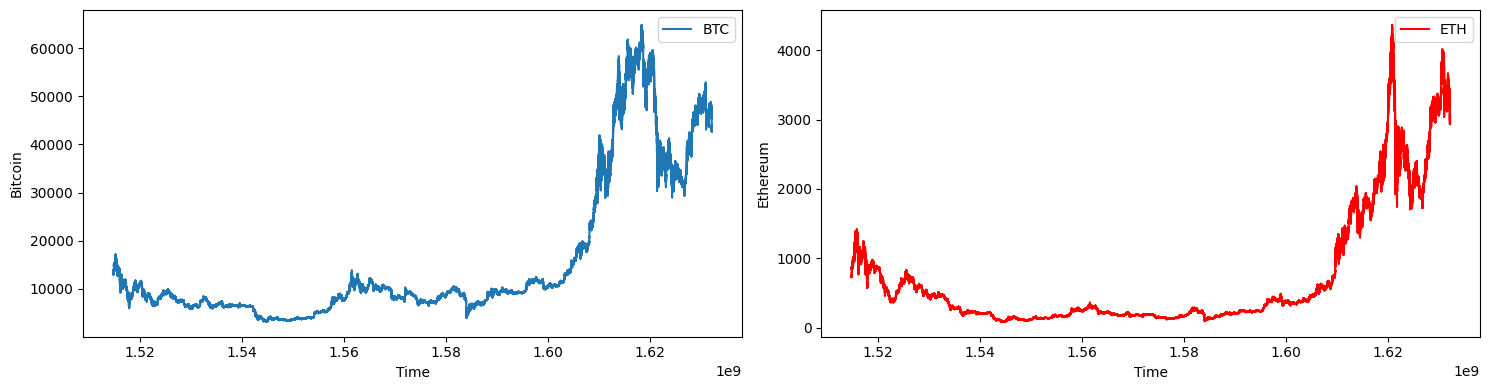

In [51]:


import matplotlib.pyplot as plt

# plot vwap time series for both chosen assets
f = plt.figure(figsize=(15,4))

# fill missing values for BTC

ax = f.add_subplot(121)
plt.plot(btc['Close'], label='BTC')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bitcoin')

ax2 = f.add_subplot(122)
ax2.plot(eth['Close'], color='red', label='ETH')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Ethereum')

plt.tight_layout()
plt.show()



The assets have quite different history, but we could check if they correlate in recent times.

In [27]:
from datetime import datetime
import time

# auxiliary function, from datetime to timestamp
totimestamp = lambda s: np.int32(time.mktime(datetime.strptime(s, "%d/%m/%Y").timetuple()))

# create intervals
btc_mini_2021 = btc.loc[totimestamp('01/06/2021'):totimestamp('01/07/2021')]
eth_mini_2021 = eth.loc[totimestamp('01/06/2021'):totimestamp('01/07/2021')]


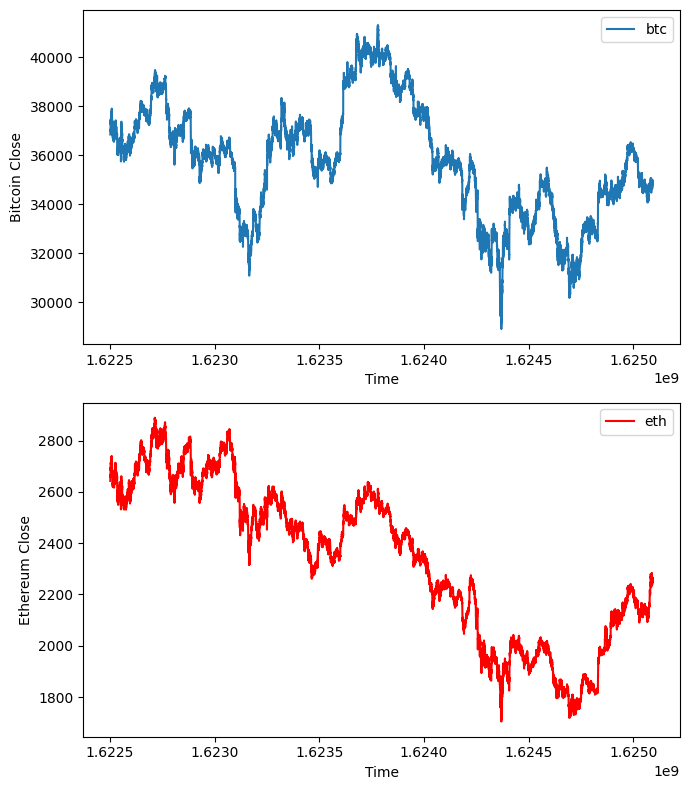

In [28]:
# plot time series for both chosen assets
f = plt.figure(figsize=(7,8))

ax = f.add_subplot(211)
plt.plot(btc_mini_2021['Close'], label='btc')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bitcoin Close')

ax2 = f.add_subplot(212)
ax2.plot(eth_mini_2021['Close'], color='red', label='eth')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Ethereum Close')

plt.tight_layout()
plt.show()

On shorter intervals we can visually see some potential correlation between both assets, with some simultaneous ups and downs. A better format for analyzing such movements is by calculating asset returns.

# Log returns

In order to analyze price changes for an asset we can deal with the price difference. However, different assets exhibit different price scales, so that the their returns are not readily comparable. We can solve this problem by computing the percentage change in price instead, also known as the return. This return coincides with the percentage change in our invested capital.

Returns are widely used in finance, however log returns are preferred for mathematical modelling of time series, as they are additive across time. Also, while regular returns cannot go below -100%, log returns are not bounded.

To compute the log return, we can simply take the logarithm of the ratio between two consecutive prices. The first row will have an empty return as the previous value is unknown, therefore the empty return data point will be dropped.

In [29]:
# define function to compute log returns
def log_return(series, periods=1):
    return np.log(series).diff(periods=periods)



We can visualize the log return for our two assets. See how the signal now looks more like white noise, with less drift than the time series for prices.


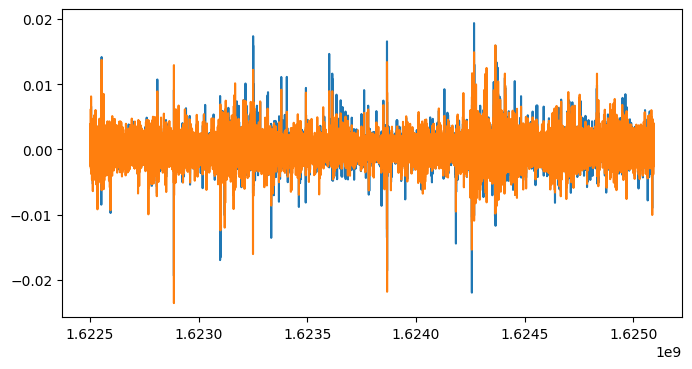

In [ ]:
import scipy.stats as stats

lret_btc = log_return(btc_mini_2021.Close)[1:]
lret_eth = log_return(eth_mini_2021.Close)[1:]


lret_btc.rename('lret_btc', inplace=True)
lret_eth.rename('lret_eth', inplace=True)

plt.figure(figsize=(8,4))
plt.plot(lret_btc);
plt.plot(lret_eth);
plt.show()

### Correlation between assets

We hypothesized before that crypto asset returns may exhibit some correlation. Let's check this in more detail now.

We can check how the correlation between Bitcoin and Ethereum change over time for the 2021 period we selected.

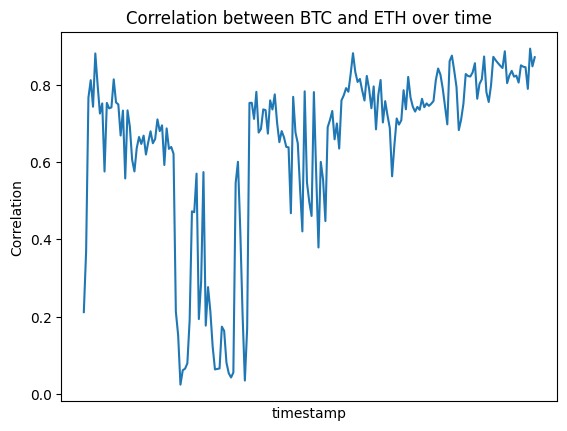

In [31]:
# join two asset in single DataFrame

lret_btc_long = log_return(btc.Close)[1:]
lret_eth_long = log_return(eth.Close)[1:]


lret_btc_long.rename('lret_btc', inplace=True)
lret_eth_long.rename('lret_eth', inplace=True)
two_assets = pd.concat([lret_btc_long, lret_eth_long], axis=1)

# group consecutive rows and use .corr() for correlation between columns
corr_time = two_assets.groupby(two_assets.index//(10000*60)).corr().loc[:,"lret_btc"].loc[:,"lret_eth"]

corr_time.plot();
plt.xticks([])
plt.ylabel("Correlation")
plt.title("Correlation between BTC and ETH over time");

Note the high but variable correlation between the assets. Here we can see that there is some changing dynamics over time, and this would be critical for this time series challenge, that is, how to perform forecasts in a highly non-stationary environment.

A stationary behaviour of a system or a process is characterized by non-changing statistical properties over time such as the mean, variance and autocorrelation. On the other hand, a non-stationary behaviour is characterized by a continuous change of statistical properties over time. Stationarity is important because many useful analytical tools and statistical tests and models rely on it.


We can also check the correlation between all assets visualizing the correlation matrix. Note how some assets have much higher pairwise correlation than others.

In [52]:


# create dataframe with returns for all assets
all_assets_2021 = pd.DataFrame([])
for asset_id, asset_name in zip(asset_details.Asset_ID, asset_details.Asset_Name):
  asset = df_train[df_train["Asset_ID"]==asset_id].set_index("timestamp")
  asset = asset.loc[totimestamp('01/01/2021'):totimestamp('01/05/2021')]
  asset = asset.reindex(range(asset.index[0],asset.index[-1]+60,60),method='pad')
  lret = log_return(asset.Close.fillna(0))[1:]
  all_assets_2021 = all_assets_2021.join(lret, rsuffix=asset_name, how="outer")



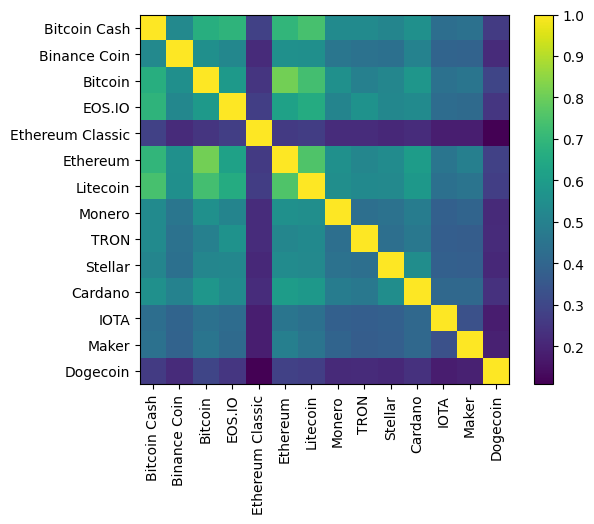

In [53]:
plt.imshow(all_assets_2021.corr());
plt.yticks(range(14), asset_details.Asset_Name.values);
plt.xticks(range(14), asset_details.Asset_Name.values, rotation='vertical');
plt.colorbar();

# Building your prediction model


Feature design¶

We first design a few relevant features to input to our model.

In [54]:
# Select some input features from the trading data: 
# 5 min log return, abs(5 min log return), upper shadow, and lower shadow.
upper_shadow = lambda asset: asset.High - np.maximum(asset.Close,asset.Open)
lower_shadow = lambda asset: np.minimum(asset.Close,asset.Open)- asset.Low

X_btc = pd.concat([log_return(btc.VWAP,periods=5), log_return(btc.VWAP,periods=1).abs(), 
               upper_shadow(btc), lower_shadow(btc)], axis=1)
y_btc = btc.Target

X_eth = pd.concat([log_return(eth.VWAP,periods=5), log_return(eth.VWAP,periods=1).abs(), 
               upper_shadow(eth), lower_shadow(eth)], axis=1)
y_eth = eth.Target

As we will train linear regression parameters, we need to separate training and test sets. To do so, we will compute X and y and split this data into train and test splits. Note that the test split represents a later part of the data, as it is commonly done in time series.

In [58]:
# select training and test periods
train_window = [totimestamp("01/05/2021"), totimestamp("30/05/2021")]
test_window = [totimestamp("01/06/2021"), totimestamp("30/06/2021")]

# divide data into train and test, compute X and y
# we aim to build simple regression models using a window_size of 1
X_btc_train = X_btc.loc[train_window[0]:train_window[1]].fillna(0).to_numpy()  # filling NaN's with zeros
y_btc_train = y_btc.loc[train_window[0]:train_window[1]].fillna(0).to_numpy()  

X_btc_test = X_btc.loc[test_window[0]:test_window[1]].fillna(0).to_numpy() 
y_btc_test = y_btc.loc[test_window[0]:test_window[1]].fillna(0).to_numpy() 

X_eth_train = X_eth.loc[train_window[0]:train_window[1]].fillna(0).to_numpy()  
y_eth_train = y_eth.loc[train_window[0]:train_window[1]].fillna(0).to_numpy()  

X_eth_test = X_eth.loc[test_window[0]:test_window[1]].fillna(0).to_numpy() 
y_eth_test = y_eth.loc[test_window[0]:test_window[1]].fillna(0).to_numpy() 

We now standardize the input data. Standardization is the process of putting different variables on the same scale. In regression analysis, it is often crucial to standardize your independent variables or you may risk obtaining misleading results.

In [59]:
from sklearn.preprocessing import StandardScaler
# simple preprocessing of the data 
scaler = StandardScaler()

X_btc_train_scaled = scaler.fit_transform(X_btc_train)
X_btc_test_scaled = scaler.transform(X_btc_test)

X_eth_train_scaled = scaler.fit_transform(X_eth_train)
X_eth_test_scaled = scaler.transform(X_eth_test)


### Baseline model: Linear Regression

We will try a simple Linear Regression model on the features we designed. Note that Linear Regression is not commonly used in time series analysis, specially with only one time step!

We compare two Linear Regression baselines, one that considers each asset independently and one multiple inputs that models all assets together.


In [61]:
from sklearn.linear_model import LinearRegression

# implement basic ML baseline (one per asset)
lr = LinearRegression()
lr.fit(X_btc_train_scaled,y_btc_train)
y_pred_lr_btc = lr.predict(X_btc_test_scaled)

lr.fit(X_eth_train_scaled,y_eth_train)
y_pred_lr_eth = lr.predict(X_eth_test_scaled)

In [62]:
# implement more complex baseline (multiple input/output regression model)
from sklearn.multioutput import MultiOutputRegressor

# we concatenate X and y for both assets
X_both_train = np.concatenate((X_btc_train_scaled, X_eth_train_scaled), axis=1)
X_both_test = np.concatenate((X_btc_test_scaled, X_eth_test_scaled), axis=1)
y_both_train = np.column_stack((y_btc_train, y_eth_train))
y_both_test = np.column_stack((y_btc_test, y_eth_test))

# define the direct multioutput model and fit it
mlr = MultiOutputRegressor(LinearRegression())
mlr.fit(X_both_train,y_both_train)
y_pred_lr_both = mlr.predict(X_both_test)

The competition performance metric is weighted correlation. However, for now we will use simple correlation to evaluate the two baseline models built.

In [63]:
print('Test score for LR baseline: BTC', f"{np.corrcoef(y_pred_lr_btc, y_btc_test)[0,1]:.2f}", 
                                ', ETH', f"{np.corrcoef(y_pred_lr_eth, y_eth_test)[0,1]:.2f}")
print('Test score for multiple output LR baseline: BTC', f"{np.corrcoef(y_pred_lr_both[:,0], y_btc_test)[0,1]:.2f}", 
                                                ', ETH', f"{np.corrcoef(y_pred_lr_both[:,1], y_eth_test)[0,1]:.2f}")

Test score for LR baseline: BTC -0.01 , ETH 0.02
Test score for multiple output LR baseline: BTC 0.01 , ETH 0.05


We can see that, for the training and test periods selected, the multiple asset LR model performs better than simply modelling each asset separately. Note that because the data is highly non-stationary, these results might vary a lot for different periods.